# Forest Disturbance Detection - Modular Training Pipeline

Clean demonstration of the modularized training workflow.
All code is now organized in the `disturbance_detection` package.

**Sections:**
1. Setup & Configuration
2. Data Loading & Preparation
3. Model Training
4. Evaluation & Visualization

### Setup and Configuration

In [1]:
import pandas as pd
import torch
import os

# Import from our modular package
from disturbance_detection import (
    Config, set_seed,
   print_split_balances, #make_or_load_uid_splits,  prepare_data, 
    UNet_1D_W3, FocalLoss,
    safe_to_device,
    final_eval_with_val_threshold,
    count_supervised_positives,
    plot_history, plot_precision_recall_curve, 
    plot_f1_vs_threshold, print_classification_report,
    get_model,
    TemporalCNN,
    UNet_1D_W30,
    UNet_1D_W5to7,
    UNet_1D_W5to7_MultiLevel_Attention,
    CaptumEvaluator,
    evaluate_position_wise_metrics,
    load_best_model_and_evaluate_position_wise_metrics,
    TemporalMultiScaleUNet
)

from disturbance_detection.preprocessing.data_preprocessing import prepare_data, make_or_load_uid_splits
print("Direct import works!")

print("All imports successful!")

Direct import works!
All imports successful!


In [2]:
# Create configuration
config = Config()

# Set random seed for reproducibility
set_seed(config.seed)

# Check device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
config.target_mode = "last"
config.window_size = 5

config.focal_alpha = 0.3 #0.8
config.focal_gamma = 1.9 #2.0
config.features_mode = "bands_indices"
config.num_epochs = 30
config.scheduler_patience = 5
config.num_workers = 8


# Display key configuration
print(f"\nConfiguration:")
print(f"  Features: {config.features_mode} ({config.get_num_features()} features)")
print(f"  Window size: {config.window_size}")
print(f"  Batch size: {config.batch_size}")
print(f"  Epochs: {config.num_epochs}")
print(f"  Learning rate: {config.learning_rate}")
print(f"  Focal loss: alpha={config.focal_alpha}, gamma={config.focal_gamma}")

Random seed set to 0
Using device: cuda:0

Configuration:
  Features: bands_indices (12 features)
  Window size: 5
  Batch size: 64
  Epochs: 30
  Learning rate: 0.0003
  Focal loss: alpha=0.3, gamma=1.9


### Dataloading and Preparation

In [3]:
# Load dataset
df = pd.read_csv(config.csv_path, index_col=0, sep=config.csv_separator)
print(f"Loaded {len(df)} samples")

# Create disturbance labels
df['class'] = df['class_level1'].apply(lambda x: 1 if x == 'disturbance' else 0)

# Filter doubtful samples (optional - from original notebook)
df = df[~((df['class_level1'] == 'treed') & (df['NBR'] < 0.5))]
df = df[~((df['class_level1'] == 'treed') & (df['NDVI'] < 0.5))]
df = df[~((df['class_level1'] == 'non-treed') & (df['NBR'] < 0.5))]
df = df[~((df['class_level1'] == 'non-treed') & (df['NDVI'] < 0.5))]
#df = df[~((df['class_level1'] == 'disturbance') & (df['NBR'] > 0.5))]
#df = df[~((df['class_level1'] == 'disturbance') & (df['NDVI'] > 0.5))]

print(f"After filtering: {len(df)} samples")
print(f"\nClass distribution:")
print(df['class_level1'].value_counts())

Loaded 567084 samples
After filtering: 524772 samples

Class distribution:
class_level1
treed          510211
disturbance      8711
non-treed        5850
Name: count, dtype: int64


In [4]:
# Prepare train/val/test splits and dataloaders
train_loader, val_loader, test_loader, n_features, features = prepare_data(df, config)

print(f"\nData preparation complete!")
print(f"Features used: {features}")
print(f"Number of features: {n_features}")
print(f"\nDataLoader sizes:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

[INFO] Loaded existing split file: /home/ubuntu/work/saved_data/landsat_disturbance_detection/clean_1D_U_Net/deep_disturbance/Data/new_class2_v5_seed42_uids_w5_v5_results.npz

Data preparation complete!
Features used: ['BLU', 'GRN', 'RED', 'NIR', 'SW1', 'SW2', 'NBR', 'NDVI', 'TCB', 'TCG', 'TCW', 'DIn']
Number of features: 12

DataLoader sizes:
  Train batches: 5006
  Val batches: 730
  Test batches: 1410


In [5]:
# Check class balance at supervised position
tr_pos, tr_tot, tr_rate = count_supervised_positives(train_loader, config.target_mode, device)
va_pos, va_tot, va_rate = count_supervised_positives(val_loader, config.target_mode, device)
te_pos, te_tot, te_rate = count_supervised_positives(test_loader, config.target_mode, device)

print(f"Class balance at target position ('{config.target_mode}'):")
print(f"  Train: {tr_pos}/{tr_tot} ({100*tr_rate:.3f}% positive)")
print(f"  Val:   {va_pos}/{va_tot} ({100*va_rate:.3f}% positive)")
print(f"  Test:  {te_pos}/{te_tot} ({100*te_rate:.3f}% positive)")

Class balance at target position ('last'):
  Train: 1336/320371 (0.417% positive)
  Val:   196/46693 (0.420% positive)
  Test:  354/90229 (0.392% positive)


In [6]:
# Check label distribution at each position in the window
import numpy as np

# Collect all labels from training data
all_labels = []
for x, y in train_loader:
    all_labels.append(y.numpy())

all_labels = np.concatenate(all_labels, axis=0)  # Shape: (N_samples, window_size)

print(f"Label distribution by position (window_size={config.window_size}):")
print("-" * 50)
for i in range(config.window_size):
    pos_name = "last" if i == config.window_size - 1 else ("center" if i == config.window_size // 2 else f"{i}")
    mean_val = all_labels[:, i].mean()
    count = int(all_labels[:, i].sum())
    total = len(all_labels)
    print(f"Position {i:2d} ({pos_name:>6s}): {mean_val:.4f} ({count}/{total} positive)")

Label distribution by position (window_size=5):
--------------------------------------------------
Position  0 (     0): 0.0033 (1060/320371 positive)
Position  1 (     1): 0.0035 (1135/320371 positive)
Position  2 (center): 0.0036 (1153/320371 positive)
Position  3 (     3): 0.0038 (1212/320371 positive)
Position  4 (  last): 0.0042 (1336/320371 positive)


In [7]:
# Investigation 1: Check if disturbances persist across consecutive years
print("=== Checking label persistence ===")

# For each unique pixel (uniqueid), check how often disturbances persist
persistence_check = []
for uid, group in df.groupby('uniqueid'):
    group = group.sort_values('year')
    labels = group['class'].values
    
    # Find transitions from 0 -->1 (disturbance starts)
    for i in range(len(labels)-1):
        if labels[i] == 1:  # if disturbed
            # check if next year is also disturbed
            persistence_check.append(labels[i+1])

if len(persistence_check) > 0:
    persistence_rate = np.mean(persistence_check)
    print(f"When a pixel is disturbed, it stays disturbed next year: {persistence_rate:.2%} of the time")
    print(f"(Based on {len(persistence_check)} disturbance-years)")
else:
    print("No consecutive disturbances found")

print("\n" + "="*60)
print("=== Checking temporal trend (disturbance rate over years) ===\n")

# Investigation 2: Check if disturbance rate changes over time
yearly_stats = df.groupby('year').agg({
    'class': ['sum', 'count', 'mean']
}).round(4)

yearly_stats.columns = ['Disturbed', 'Total', 'Rate']
print(yearly_stats)

print(f"\nFirst year rate: {yearly_stats['Rate'].iloc[0]:.4f}")
print(f"Last year rate: {yearly_stats['Rate'].iloc[-1]:.4f}")
print(f"Increase: {(yearly_stats['Rate'].iloc[-1] / yearly_stats['Rate'].iloc[0] - 1)*100:.1f}%")

=== Checking label persistence ===
When a pixel is disturbed, it stays disturbed next year: 50.17% of the time
(Based on 8196 disturbance-years)

=== Checking temporal trend (disturbance rate over years) ===

      Disturbed  Total    Rate
year                          
1985        172  14536  0.0118
1986        187  15243  0.0123
1987        204  15457  0.0132
1988        182  15265  0.0119
1989        191  15388  0.0124
1990        201  15280  0.0132
1991        189  15686  0.0120
1992        226  15343  0.0147
1993        212  15338  0.0138
1994        201  15350  0.0131
1995        201  15715  0.0128
1996        222  15691  0.0141
1997        237  15770  0.0150
1998        254  15888  0.0160
1999        267  15858  0.0168
2000        325  15654  0.0208
2001        239  15825  0.0151
2002        282  15933  0.0177
2003        306  15735  0.0194
2004        297  15995  0.0186
2005        311  16025  0.0194
2006        350  16013  0.0219
2007        344  15768  0.0218
2008        341 

### Model Training

In [8]:
# Initialize model

#Select model
#config.model_name = "TemporalCNN"
#model = get_model(config)


#or train UNet
config.model_name = "UNet_1D_W5to7"
#config.model_name = "UNet_1D_W30"
#config.model_name = "UNet_1D_W3"
#config.model_name = "UNet_1D_W5to7_MultiLevel_Attention"
#config.model_name = "TemporalMultiScaleUNet"
config.dropout_rate = 0.4
model = get_model(config).to(device)


# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model created: {config.model_name}")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")

Model created: UNet_1D_W5to7
  Total parameters: 127,225
  Trainable parameters: 127,225


In [9]:
import torch.nn as nn

# Create optimizer
'''optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config.learning_rate,
    weight_decay=config.weight_decay,
    betas=config.betas,
    eps=config.eps
)'''

config.learning_rate = 0.001



optimizer = torch.optim.Adam(
    model.parameters(),
    lr=config.learning_rate,
    betas=config.betas,
    eps=config.eps
)


# Create loss function
loss_fn = FocalLoss(
    alpha=config.focal_alpha,
    gamma=config.focal_gamma,
    reduction=config.loss_reduction
)


print("Optimizer: Adam")
print(f"  Learning rate: {config.learning_rate}")
print(f"  Weight decay: {config.weight_decay}")
print(f"\nLoss: FocalLoss")
print(f"  Alpha: {config.focal_alpha}")
print(f"  Gamma: {config.focal_gamma}")

Optimizer: Adam
  Learning rate: 0.001
  Weight decay: 0.0001

Loss: FocalLoss
  Alpha: 0.3
  Gamma: 1.9


In [10]:
from disturbance_detection.training import train_full_supervision_with_selection

# Train with best model selection
print(f"\nStarting training for {config.num_epochs} epochs...")
print(f"Model: {config.model_name}")
print(f"Target position: {config.target_mode}")
print(f"Model selection by: {config.select_by}")
print(f"Window size: {config.window_size}")
print(f"Batch size: {config.batch_size}")
print("-" * 80)


config.norm_type = "bn"
config.dropout_rate = 0.4
config.batch_size = 32

history, best_info = train_full_supervision_with_selection(
    model, train_loader, val_loader, optimizer, device, loss_fn, config
)

print("-" * 80)
print(f"\nTraining complete!")
print(f"Best epoch: {best_info['best_epoch']}")
print(f"Best {best_info['select_by']}: {best_info['best_metric']:.4f}")
print(f"Checkpoint saved: {best_info['ckpt_path']}")


Starting training for 30 epochs...
Model: UNet_1D_W5to7
Target position: last
Model selection by: auprc
Window size: 5
Batch size: 64
--------------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 01 | TrainLoss 0.0024 | TrainF1(all) 0.2646 | TrainF1(target) 0.2628 | TrainPrecision 0.2700 | TrainRecall 0.2593 | ValLoss 0.0008 | ValF1(all) 0.5823 | ValF1* 0.8000 | ValAUPRC 0.8416 | ValPrecision 0.9804 | ValRecall 0.2551
Epoch 02 | TrainLoss 0.0009 | TrainF1(all) 0.6006 | TrainF1(target) 0.6116 | TrainPrecision 0.8607 | TrainRecall 0.4612 | ValLoss 0.0008 | ValF1(all) 0.5899 | ValF1* 0.8112 | ValAUPRC 0.8632 | ValPrecision 0.9619 | ValRecall 0.5153
Epoch 03 | TrainLoss 0.0008 | TrainF1(all) 0.6352 | TrainF1(target) 0.6747 | TrainPrecision 0.8694 | TrainRecall 0.5003 | ValLoss 0.0007 | ValF1(all) 0.6911 | ValF1* 0.8138 | ValAUPRC 0.8689 | ValPrecision 0.9500 | ValRecall 0.5816
Epoch 04 | TrainLoss 0.0008 | TrainF1(all) 0.6491 | TrainF1(target) 0.6740 | TrainPrecision 0.8719 | TrainRecall 0.5170 | ValLoss 0.0006 | ValF1(all) 0.7363 | ValF1* 0.8304 | ValAUPRC 0.8814 | ValPrecision 0.8779 | ValRecall 0.7704
Epoch 05 | TrainLoss 0.0007 | TrainF1(all) 0.6686 | TrainF1(target) 0.70

### Evaluation and Visualization

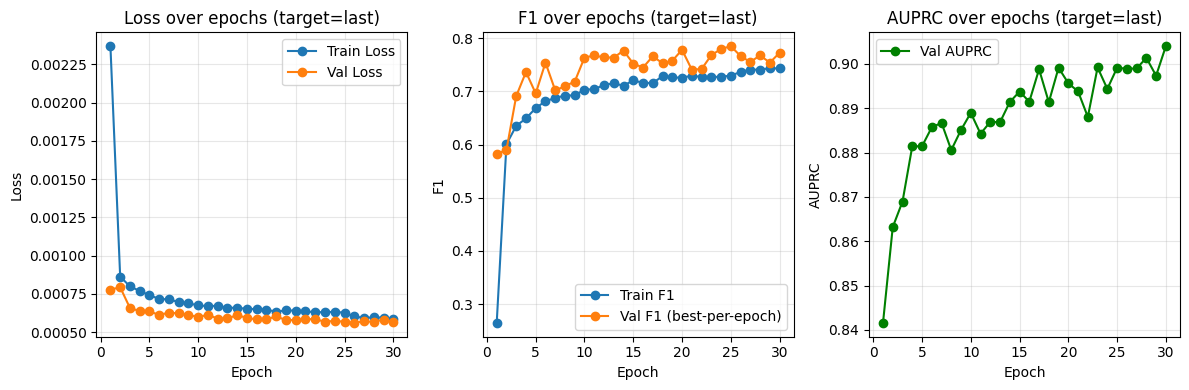

In [11]:
# Import the function with a different name
from disturbance_detection.evaluations import plot_history as plot_training_history

# Create a mapping for the plot function
plot_data = {
    "train_loss": history["train_loss"],
    "val_loss": history["val_loss"],
    "train_f1": history["train_f1_all"],  # Use f1_all as the main F1
    "val_f1": history["val_f1_all"],      # Use f1_all as the main F1
    "val_auprc": history["val_auprc"]
}

# Then plot
plot_training_history(plot_data, title_suffix=f" (target={config.target_mode})")

Position 0: F1=0.745, Precision=0.741, Recall=0.750
Position 1: F1=0.823, Precision=0.877, Recall=0.776
Position 2: F1=0.831, Precision=0.899, Recall=0.773
Position 3: F1=0.830, Precision=0.898, Recall=0.772
Position 4: F1=0.851, Precision=0.859, Recall=0.842


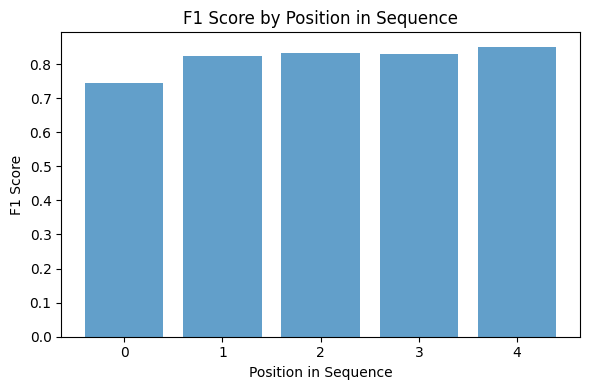

In [12]:
# Get position-wise metrics
import matplotlib.pyplot as plt

position_metrics = evaluate_position_wise_metrics(model, val_loader, device, config)

#Print position-wise metrics
for pos, metrics in enumerate(position_metrics):
    print(f"Position {pos}: F1={metrics['f1']:.3f}, Precision={metrics['precision']:.3f}, Recall={metrics['recall']:.3f}")


positions = [metrics['position'] for metrics in position_metrics]
f1_scores = [metrics['f1'] for metrics in position_metrics]

plt.figure(figsize=(6, 4))
plt.bar(positions, f1_scores, alpha=0.7)
plt.xlabel('Position in Sequence')
plt.ylabel('F1 Score')
plt.title('F1 Score by Position in Sequence')
#plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
#plt.savefig('position_wise_f1.png', dpi=150)
plt.show()

In [13]:
# Load best model and evaluate
print("Evaluating best model on test set...")
print("=" * 80)

best_thr, test_metrics = final_eval_with_val_threshold(
    model, device, config.checkpoint_path,
    val_loader, test_loader, 
    target_mode=config.target_mode
)

print("=" * 80)

Evaluating best model on test set...
Loaded best model from epoch 30.


/home/ubuntu/work/saved_data/landsat_disturbance_detection/clean_1D_U_Net/deep_disturbance/disturbance_detection/evaluations/evaluation.py:183: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experim

[VAL] thr*=0.351 | F1*=0.851 | AUPRC=0.904
[TEST] thr=0.351 | P=0.852 R=0.780 F1=0.814 Acc=0.999 | AUPRC=0.858
Confusion matrix (TEST) [rows=true 0/1, cols=pred 0/1]:
 [[89827    48]
 [   78   276]]


In [14]:
from disturbance_detection.evaluations import collect_probs

# Collect test predictions
y_true_test, y_prob_test = collect_probs(model, test_loader, device, config.target_mode)

# Print detailed classification report
print_classification_report(
    y_true_test, y_prob_test, best_thr,
    target_names=["Undisturbed (0)", "Disturbed (1)"]
)

Accuracy: 0.999

Classification Report:
                 precision    recall  f1-score   support

Undisturbed (0)      0.999     0.999     0.999     89875
  Disturbed (1)      0.852     0.780     0.814       354

       accuracy                          0.999     90229
      macro avg      0.925     0.890     0.907     90229
   weighted avg      0.999     0.999     0.999     90229



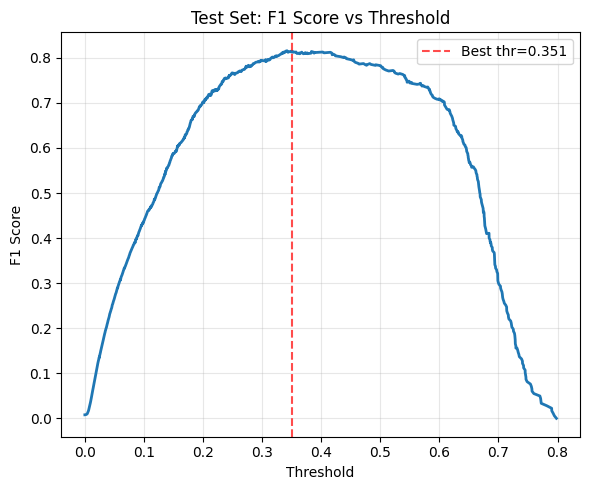

In [15]:
# F1 score as a function of threshold
plot_f1_vs_threshold(y_true_test, y_prob_test, best_thr, 
                     "Test Set: F1 Score vs Threshold")

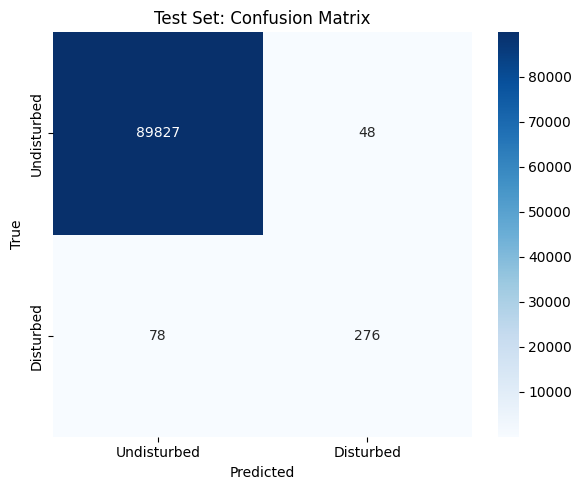

In [16]:
from disturbance_detection.evaluations import plot_confusion_matrix

# Plot confusion matrix
plot_confusion_matrix(test_metrics['cm'], 
                     labels=["Undisturbed", "Disturbed"],
                     title="Test Set: Confusion Matrix")

In [ ]:
def quick_evaluation(model, test_loader, config, device, num_samples: int = 3):
    """Quick attribution evaluation - just run this function!"""
    
    evaluator = CaptumEvaluator(model, device, config)
    
    # Find positive samples
    positive_samples = []
    for batch_x, batch_y in test_loader:
        for i in range(batch_x.shape[0]):
            if batch_y[i, -1] == 1:  # Disturbance at last timestep
                positive_samples.append(batch_x[i:i+1])
                if len(positive_samples) >= num_samples:
                    break
        if len(positive_samples) >= num_samples:
            break
    
    if not positive_samples:
        print("No positive samples found!")
        return
    
    print(f"Analyzing {len(positive_samples)} disturbance samples...")
    
    # Analyze each sample
    for i, sample in enumerate(positive_samples):
        print(f"\n--- Sample {i+1} ---")
        
        # Get prediction - handle different output formats
        with torch.no_grad():
            logits = model(sample.to(device))
            
            # Handle different model output formats
            if len(logits.shape) > 1 and logits.shape[1] > 1:
                # Model outputs (batch_size, time_steps) - take target position
                if config.target_mode == "last":
                    target_logit = logits[0, -1]
                elif config.target_mode == "center":
                    center_idx = config.window_size // 2
                    target_logit = logits[0, center_idx]
                else:
                    target_logit = logits[0, -1]  # Default to last
            else:
                # Model outputs single value per sample
                target_logit = logits[0] if len(logits.shape) > 0 else logits
            
            pred = torch.sigmoid(target_logit)
            print(f"Model prediction: {pred.item():.3f}")
        
        # Get attributions
        ig_attr = evaluator.get_attribution(sample, 'integrated_gradients')
        sal_attr = evaluator.get_attribution(sample, 'saliency')
        
        # Plot results
        evaluator.plot_heatmap(ig_attr, f"Sample {i+1} - Integrated Gradients")
        evaluator.plot_summary(ig_attr, f"Sample {i+1} - Integrated Gradients Summary")
        
        evaluator.plot_heatmap(sal_attr, f"Sample {i+1} - Saliency")
        evaluator.plot_summary(sal_attr, f"Sample {i+1} - Saliency Summary")

quick_evaluation(model, test_loader, config, device, num_samples=3)

ValueError: not enough values to unpack (expected 3, got 2)